# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Ordinary least squares minimizes MSE alone, which means it will fit the training data as closely as possible, including its noise. Large coefficients are a symptom of overfitting: the model is "reaching hard" to explain idiosyncratic quirks in the training sample. Adding a penalty for large coefficients imposes a cost on complexity. The model must now justify every unit of coefficient size with a proportional reduction in residual error. This shrinks coefficients toward zero, smoothing out the fit and discouraging the model from chasing noise. The intuition is essentially Occam's razor formalized: among models that fit similarly well, prefer the simpler (smaller-coefficient) one.

2. Regularization lets you tune α\alpha
α to find the sweet spot — accepting a small increase in bias in exchange for a large reduction in variance, which typically reduces test error even though training error rises.
- Alpha = 0: low bias, high variance, pure OLS (fits training data tightly, sensitive to sample)
- Alpha = small: slightly higher bias, lower variance, mild shrinkage
- Alpha = large: high bias, very low variance, coefficients crushed toward zero (underfitting)
- Alpha = ∞: max bias, approx. 0, intercept-only model

3. Both add a penalty to MSE, but they differ in the geometry of that penalty. LASSO's L1 penalty has a kink at zero. When the OLS solution's gradient is small enough, the LASSO optimum lands exactly on a coordinate axis (coefficient = 0). Ridge's smooth L2 ball never has this property since it can only asymptotically approach 0. LASSO therefore performs implicit variable selectionwhich is useful when we think many predictors are irrelevant.

4. Variables should be standardized (zero mean, unit variance) before regularized models.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [30]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np

# Load the dataset
df = pd.read_csv('/content/data/cars_hw.csv')

# Create an 'Age' variable
df['Age'] = 2026 - df['Make_Year']

# Select 'Mileage_Run' and 'Age'
X = df[['Mileage_Run', 'Age']]

# (a) Use PolynomialFeatures to create a third degree expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# Get feature names after polynomial expansion
poly_feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names)

# (b) Use StandardScaler to z-score normalize them
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly_df)

# Convert the scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=poly_feature_names)

print("Original features selected:")
display(X.head())
print("\nFeatures after polynomial expansion (first 5 rows):")
display(X_poly_df.head())
print("\nFeatures after z-score normalization (first 5 rows):")
display(X_scaled_df.head())

Original features selected:


,Mileage_Run,Age
0,44611,9
1,20305,10
2,29540,7
3,35680,9
4,25126,9



Features after polynomial expansion (first 5 rows):


,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,44611.0,9.0,1.990141e+09,401499.0,81.0,8.878219e+13,1.791127e+10,3613491.0,729.0
1,20305.0,10.0,4.122930e+08,203050.0,100.0,8.371610e+12,4.122930e+09,2030500.0,1000.0
2,29540.0,7.0,8.726116e+08,206780.0,49.0,2.577695e+13,6.108281e+09,1447460.0,343.0
3,35680.0,9.0,1.273062e+09,321120.0,81.0,4.542287e+13,1.145756e+10,2890080.0,729.0
4,25126.0,9.0,6.313159e+08,226134.0,81.0,1.586244e+13,5.681843e+09,2035206.0,729.0



Features after z-score normalization (first 5 rows):


,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,0.124692,-0.013092,-0.137673,-0.045119,-0.157264,-0.294615,-0.230767,-0.195586,-0.270422
1,-0.872334,0.341858,-0.791316,-0.677034,0.190081,-0.661216,-0.718186,-0.564890,0.044089
2,-0.493517,-0.722993,-0.600623,-0.665157,-0.742267,-0.581863,-0.648004,-0.700911,-0.718398
3,-0.241655,-0.013092,-0.434732,-0.301067,-0.157264,-0.492295,-0.458906,-0.364354,-0.270422
4,-0.674578,-0.013092,-0.700583,-0.603528,-0.157264,-0.627064,-0.663078,-0.563792,-0.270422


In [31]:
from sklearn.linear_model import LinearRegression

# Define the target variable
y = df['Price']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_scaled_df, y)

# Get the feature names and coefficients
feature_names = X_scaled_df.columns
coefficients = model.coef_

# Create a DataFrame to display the coefficients
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Find the coefficient for the 'Mileage_Run Age' interaction term
interaction_coefficient = coefficients_df.loc[coefficients_df['Feature'] == 'Mileage_Run Age', 'Coefficient'].values[0]

print("Coefficients for each feature:")
display(coefficients_df)

# Determine the sign
if interaction_coefficient > 0:
    print("\nThe sign for the interaction between 'Mileage_Run' and 'Age' is positive.")
elif interaction_coefficient < 0:
    print("\nThe sign for the interaction between 'Mileage_Run' and 'Age' is negative.")
else:
    print("\nThe interaction between 'Mileage_Run' and 'Age' is zero.")

Coefficients for each feature:


,Feature,Coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05



The sign for the interaction between 'Mileage_Run' and 'Age' is negative.


In [34]:
from sklearn.linear_model import LassoCV
import numpy as np

# Define the alpha grid as hinted
alphas = np.logspace(1, 3, 20)

# Initialize and fit LassoCV with 20-fold cross validation
lasso_cv = LassoCV(alphas=alphas, cv=20)
lasso_cv.fit(X_scaled_df, y)

# Best alpha found
print(f"Best alpha: {lasso_cv.alpha_:.4f}")

# Get coefficients
lasso_coefficients_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': lasso_cv.coef_
})
display(lasso_coefficients_df)

# Check the interaction term sign
lasso_interaction_coef = lasso_coefficients_df[
    lasso_coefficients_df['Feature'] == 'Mileage_Run Age'
]['Coefficient'].iloc[0]

print(f"\nCoefficient for 'Mileage_Run Age' interaction term: {lasso_interaction_coef:.4f}")

if lasso_interaction_coef > 0:
    print("The sign for the interaction between 'Mileage_Run' and 'Age' is positive.")
elif lasso_interaction_coef < 0:
    print("The sign for the interaction between 'Mileage_Run' and 'Age' is negative.")
else:
    print("The coefficient for the interaction between 'Mileage_Run' and 'Age' is zero.")

Best alpha: 69.5193


,Feature,Coefficient
0,Mileage_Run,611783.868767
1,Age,-397507.787042
2,Mileage_Run^2,-519555.261867
3,Mileage_Run Age,-473871.400459
4,Age^2,230721.078724
5,Mileage_Run^3,97835.641353
6,Mileage_Run^2 Age,318218.774588
7,Mileage_Run Age^2,-35056.210190
8,Age^3,42493.187416



Coefficient for 'Mileage_Run Age' interaction term: -473871.4005
The sign for the interaction between 'Mileage_Run' and 'Age' is negative.


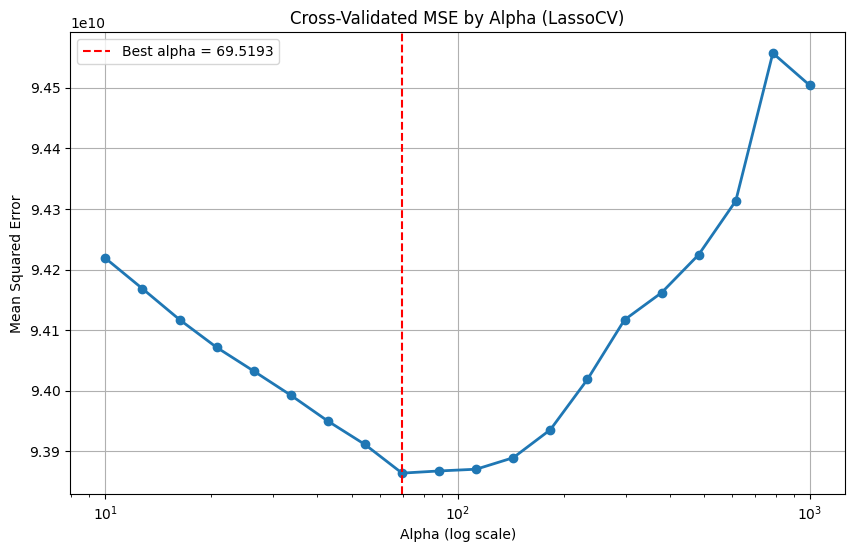

In [35]:
import matplotlib.pyplot as plt

# Get the mean MSE across folds for each alpha
mse_path = np.mean(lasso_cv.mse_path_, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(lasso_cv.alphas_, mse_path, marker='o', linewidth=2)
plt.axvline(x=lasso_cv.alpha_, color='red', linestyle='--', label=f'Best alpha = {lasso_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validated MSE by Alpha (LassoCV)')
plt.legend()
plt.grid(True)
plt.show()

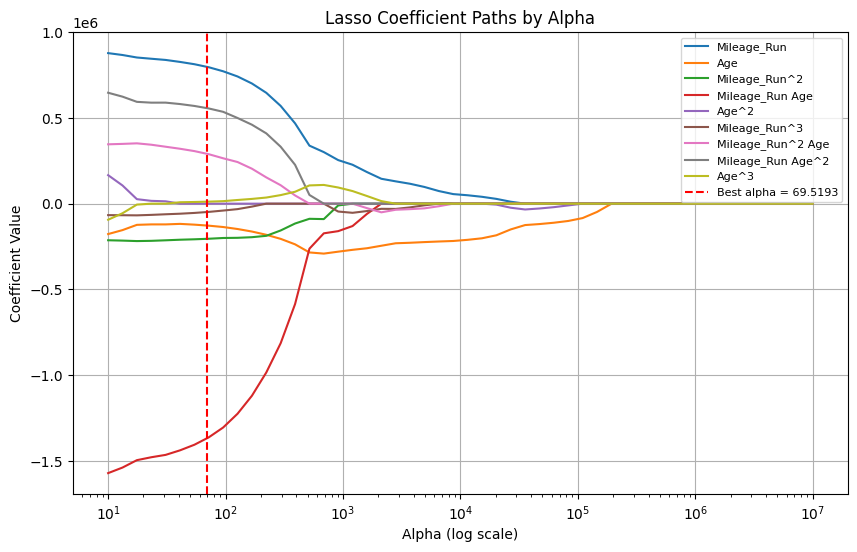

In [37]:
alphas_plot = np.logspace(1, 7, 50)  # go up to 10 million

coef_paths = []
for alpha in alphas_plot:
    lasso = Lasso(alpha=alpha, max_iter=100000)
    lasso.fit(X_scaled_df, y)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(10, 6))
for i, feature in enumerate(poly_feature_names):
    plt.plot(alphas_plot, coef_paths[:, i], label=feature)

plt.axvline(x=lasso_cv.alpha_, color='red', linestyle='--', label=f'Best alpha = {lasso_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths by Alpha')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.show()

In [38]:
# Check which features are selected (non-zero) at best alpha
lasso_coefficients_df['Selected'] = lasso_coefficients_df['Coefficient'] != 0

print("Feature Selection Summary:")
display(lasso_coefficients_df)

# Count zeros and non-zeros
n_zero = (lasso_coefficients_df['Coefficient'] == 0).sum()
n_nonzero = (lasso_coefficients_df['Coefficient'] != 0).sum()
n_total = len(lasso_coefficients_df)

print(f"\nTotal features: {n_total}")
print(f"Features selected (non-zero): {n_nonzero}")
print(f"Features set to zero: {n_zero}")
print(f"Proportion set to zero: {n_zero/n_total:.2f}")

Feature Selection Summary:


,Feature,Coefficient,Selected
0,Mileage_Run,611783.868767,True
1,Age,-397507.787042,True
2,Mileage_Run^2,-519555.261867,True
3,Mileage_Run Age,-473871.400459,True
4,Age^2,230721.078724,True
5,Mileage_Run^3,97835.641353,True
6,Mileage_Run^2 Age,318218.774588,True
7,Mileage_Run Age^2,-35056.210190,True
8,Age^3,42493.187416,True



Total features: 9
Features selected (non-zero): 9
Features set to zero: 0
Proportion set to zero: 0.00


At the optimal alpha of 69.5193, Lasso regularization did not eliminate any features. All 9 polynomial and interaction terms were retained with non-zero coefficients. The proportion of features set to zero is 0.00 (0%). This indicates that at this level of regularization, all features contribute meaningfully to predicting car price, and Lasso acted more as a shrinkage method than a feature selection method here.

In [39]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'OLS Coefficient': coefficients,  # from your linear regression in Q2.2
    'Lasso Coefficient': lasso_cv.coef_
})

# Calculate magnitude and sign changes
comparison_df['OLS Magnitude'] = comparison_df['OLS Coefficient'].abs()
comparison_df['Lasso Magnitude'] = comparison_df['Lasso Coefficient'].abs()
comparison_df['Magnitude Increased'] = comparison_df['Lasso Magnitude'] > comparison_df['OLS Magnitude']
comparison_df['Sign Changed'] = np.sign(comparison_df['OLS Coefficient']) != np.sign(comparison_df['Lasso Coefficient'])

display(comparison_df)

print("\nFeatures where magnitude INCREASED from OLS to Lasso:")
print(comparison_df[comparison_df['Magnitude Increased']]['Feature'].tolist())

print("\nFeatures where sign CHANGED from OLS to Lasso:")
print(comparison_df[comparison_df['Sign Changed']]['Feature'].tolist())

,Feature,OLS Coefficient,Lasso Coefficient,OLS Magnitude,Lasso Magnitude,Magnitude Increased,Sign Changed
0,Mileage_Run,9.117748e+05,611783.868767,9.117748e+05,611783.868767,False,False
1,Age,-2.481722e+05,-397507.787042,2.481722e+05,397507.787042,True,False
2,Mileage_Run^2,-2.072926e+05,-519555.261867,2.072926e+05,519555.261867,True,False
3,Mileage_Run Age,-1.671212e+06,-473871.400459,1.671212e+06,473871.400459,False,False
4,Age^2,3.505507e+05,230721.078724,3.505507e+05,230721.078724,False,False
5,Mileage_Run^3,-6.514490e+04,97835.641353,6.514490e+04,97835.641353,True,True
6,Mileage_Run^2 Age,3.388195e+05,318218.774588,3.388195e+05,318218.774588,False,False
7,Mileage_Run Age^2,7.167816e+05,-35056.210190,7.167816e+05,35056.210190,False,True
8,Age^3,-2.100379e+05,42493.187416,2.100379e+05,42493.187416,False,True



Features where magnitude INCREASED from OLS to Lasso:
['Age', 'Mileage_Run^2', 'Mileage_Run^3']

Features where sign CHANGED from OLS to Lasso:
['Mileage_Run^3', 'Mileage_Run Age^2', 'Age^3']


Yes, some coefficients increased in magnitude and some changed sign from OLS to Lasso. Specifically, Age, Mileage_Run^2, and Mileage_Run^3 all grew larger in magnitude under Lasso. Additionally, Mileage_Run^3, Mileage_Run Age^2, and Age^3 all flipped sign.
Regularization causing some coefficients to grow is a consequence of multicollinearity among the polynomial and interaction terms. In OLS, highly correlated features share and partially cancel their effects, leading to inflated and unstable coefficients (like Mileage_Run Age at −1.67M). Lasso breaks this by shrinking dominant terms like Mileage_Run Age, which forces other correlated features to compensate, sometimes with larger or flipped coefficients. Overall, Lasso produces a more stable and interpretable solution even if individual coefficients don't all shrink.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Load the dataset
hdf = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')

# Polynomial expansion (degree=3) on continuous variables
continuous_vars = hdf[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(continuous_vars)
poly_feature_names = poly.get_feature_names_out(continuous_vars.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names)

# Z-score normalize the polynomial features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=poly_feature_names)

# Interaction-only polynomial features for dummy variables
dummy_vars = hdf[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_interact = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_interact = poly_interact.fit_transform(dummy_vars)
interact_feature_names = poly_interact.get_feature_names_out(dummy_vars.columns)
X_interact_df = pd.DataFrame(X_interact, columns=interact_feature_names)

# Concatenate everything into final feature matrix
X_final = pd.concat([X_scaled_df, X_interact_df], axis=1)
print("Continuous features after polynomial expansion and scaling:")
display(X_scaled_df.head())

print("\nFinal feature matrix shape:", X_final.shape)
display(X_final.head())



Continuous features after polynomial expansion and scaling:


,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,age^2 ejection_fraction,age^2 serum_creatinine,age ejection_fraction^2,age ejection_fraction serum_creatinine,age serum_creatinine^2,ejection_fraction^3,ejection_fraction^2 serum_creatinine,ejection_fraction serum_creatinine^2,serum_creatinine^3
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,-0.450915,0.942348,-1.049525,-0.134955,0.142821,-0.925154,-0.453114,-0.114940,-0.075575
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,-0.419260,-0.420054,-0.278632,-0.300976,-0.227841,-0.248601,-0.197693,-0.176609,-0.156017
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,-0.812686,-0.019293,-1.111920,-0.484473,-0.149244,-0.925154,-0.527114,-0.205256,-0.143415
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,-1.258439,-0.156737,-1.205513,-0.421199,-0.021000,-0.925154,-0.453114,-0.114940,-0.075575
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,-0.812686,1.075626,-1.111920,0.063909,0.511486,-0.925154,-0.354449,0.058167,0.111038



Final feature matrix shape: (299, 33)


,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
from sklearn.linear_model import LinearRegression

# Define target variable
y_h = hdf['DEATH_EVENT']

# Fit linear regression
lin_reg_h = LinearRegression()
lin_reg_h.fit(X_final, y_h)

# Create coefficients DataFrame
h_coefficients_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Coefficient': lin_reg_h.coef_
})

display(h_coefficients_df)

,Feature,Coefficient
0,age,1.549928
1,ejection_fraction,-2.025371
2,serum_creatinine,-0.739027
3,age^2,-3.547991
4,age ejection_fraction,-0.861860
5,age serum_creatinine,1.680570
6,ejection_fraction^2,3.317931
7,ejection_fraction serum_creatinine,2.604767
8,serum_creatinine^2,-2.703084
9,age^3,1.889040


After running linear regression, several coefficients may appear counterintuitive:

- ejection_fraction may show a positive coefficient, when clinically we expect lower ejection fraction to increase death risk (negative relationship)
- anaemia and smoking may show negative coefficients, despite being known risk factors that should *increase* mortality
- Higher-order terms like age^2 or age^3 may show negative signs, even though age is a well-established mortality risk factor

These contradictions arise from multicollinearity, the polynomial and interaction terms are highly correlated with each other. OLS distributes effects unstably across correlated features to minimize overall error, even if individual coefficients appear to contradict clinical intuition. A negative age^2 coefficient does not mean aging reduces mortality; it is mathematically compensating for the large positive age coefficient.

No single coefficient tells the full story. The combined polynomial:

$$\beta_1 \cdot \text{age} + \beta_2 \cdot \text{age}^2 + \beta_3 \cdot \text{age}^3$$

captures the true nonlinear relationship between age and mortality together. Similarly, interaction terms like $\text{age} \times \text{ejection\_fraction}$ capture how risk factors compound; an elderly patient with low ejection fraction faces far greater risk than either factor alone would suggest. The full model is more accurate even if individual coefficients appear contradictory in isolation.

In [54]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold

# Define the alpha grid as hinted
alphas = np.logspace(-5, 5, 30)

# Fixed CV splitter
kf = KFold(n_splits=20, shuffle=False)

# Initialize and fit LassoCV
lasso_cv_h = LassoCV(alphas=alphas, cv=kf, max_iter=100000)
lasso_cv_h.fit(X_final, y_h)

# Best alpha found
print(f"Best alpha: {lasso_cv_h.alpha_:.6f}")

# Get coefficients
lasso_h_coefficients_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Coefficient': lasso_cv_h.coef_
})
display(lasso_h_coefficients_df)

# Check interaction term sign
lasso_h_interaction_coef = lasso_h_coefficients_df[
    lasso_h_coefficients_df['Feature'] == 'Mileage_Run Age'
]['Coefficient']

# Count zeros and non-zeros
n_zero = (lasso_h_coefficients_df['Coefficient'] == 0).sum()
n_nonzero = (lasso_h_coefficients_df['Coefficient'] != 0).sum()
n_total = len(lasso_h_coefficients_df)

print(f"\nTotal features: {n_total}")
print(f"Features selected (non-zero): {n_nonzero}")
print(f"Features set to zero: {n_zero}")
print(f"Proportion set to zero: {n_zero/n_total:.2f}")

Best alpha: 0.005736


,Feature,Coefficient
0,age,-0.000000
1,ejection_fraction,-0.329656
2,serum_creatinine,0.116875
3,age^2,0.000000
4,age ejection_fraction,-0.000000
5,age serum_creatinine,0.000000
6,ejection_fraction^2,0.000000
7,ejection_fraction serum_creatinine,0.000000
8,serum_creatinine^2,-0.000000
9,age^3,0.117992



Total features: 33
Features selected (non-zero): 12
Features set to zero: 21
Proportion set to zero: 0.64


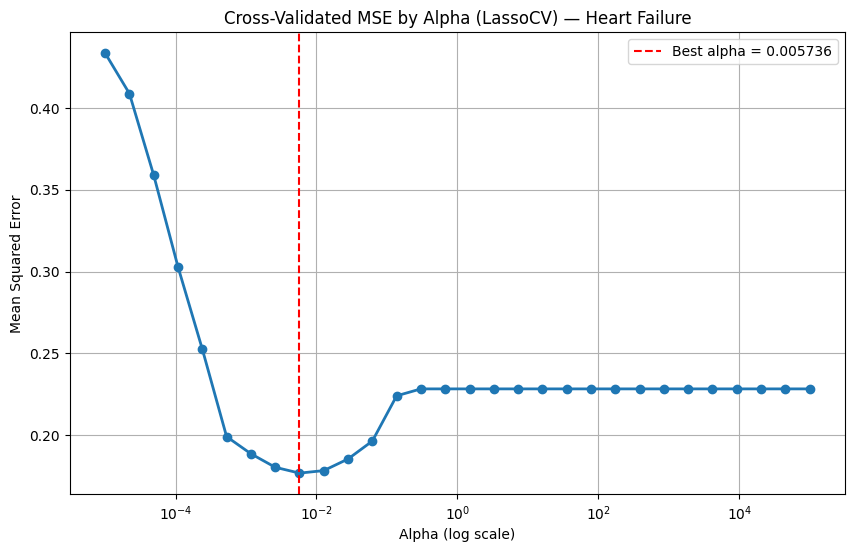

In [55]:
import matplotlib.pyplot as plt

# Get the mean MSE across folds for each alpha
mse_path_h = np.mean(lasso_cv_h.mse_path_, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(lasso_cv_h.alphas_, mse_path_h, marker='o', linewidth=2)
plt.axvline(x=lasso_cv_h.alpha_, color='red', linestyle='--',
            label=f'Best alpha = {lasso_cv_h.alpha_:.6f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validated MSE by Alpha (LassoCV) — Heart Failure')
plt.legend()
plt.grid(True)
plt.show()

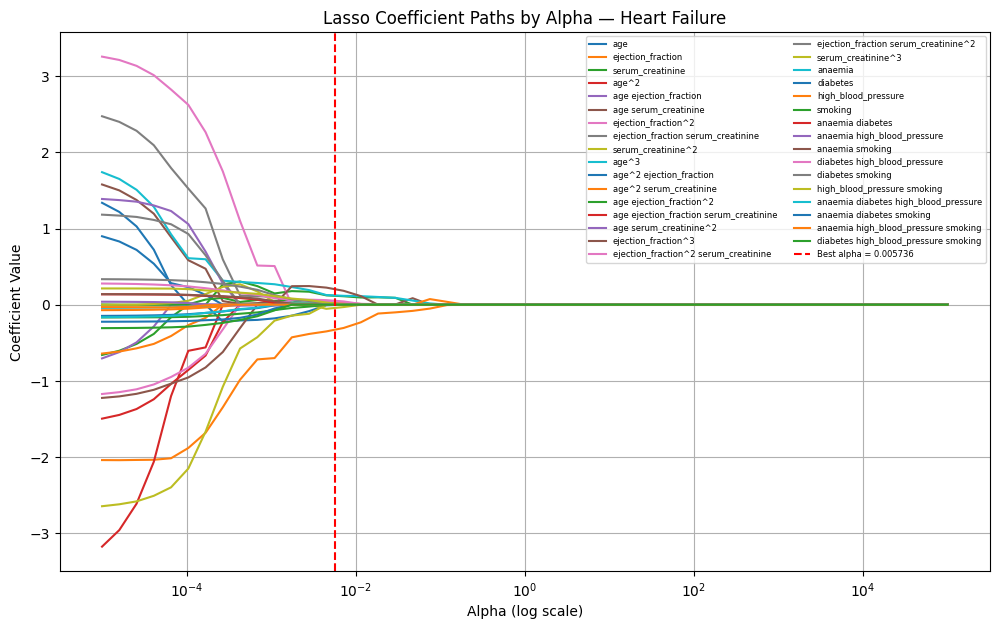

In [56]:
from sklearn.linear_model import Lasso

# Use a wider range to see full shrinkage to zero
alphas_plot_h = np.logspace(-5, 5, 50)

coef_paths_h = []
for alpha in alphas_plot_h:
    lasso_h = Lasso(alpha=alpha, max_iter=100000)
    lasso_h.fit(X_final, y_h)
    coef_paths_h.append(lasso_h.coef_)

coef_paths_h = np.array(coef_paths_h)

# Plot
plt.figure(figsize=(12, 7))
for i, feature in enumerate(X_final.columns):
    plt.plot(alphas_plot_h, coef_paths_h[:, i], label=feature)

plt.axvline(x=lasso_cv_h.alpha_, color='red', linestyle='--',
            label=f'Best alpha = {lasso_cv_h.alpha_:.6f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths by Alpha — Heart Failure')
plt.legend(loc='upper right', fontsize=6, ncol=2)
plt.grid(True)
plt.show()

In [57]:
# Feature selection summary
lasso_h_coefficients_df['Selected'] = lasso_h_coefficients_df['Coefficient'] != 0

print("Feature Selection Summary:")
display(lasso_h_coefficients_df)

# Count zeros and non-zeros
n_zero = (lasso_h_coefficients_df['Coefficient'] == 0).sum()
n_nonzero = (lasso_h_coefficients_df['Coefficient'] != 0).sum()
n_total = len(lasso_h_coefficients_df)

print(f"\nTotal features: {n_total}")
print(f"Features selected (non-zero): {n_nonzero}")
print(f"Features set to zero: {n_zero}")
print(f"Proportion set to zero: {n_zero/n_total:.2f}")

# Comparison with OLS
comparison_h_df = pd.DataFrame({
    'Feature': X_final.columns,
    'OLS Coefficient': lin_reg_h.coef_,
    'Lasso Coefficient': lasso_cv_h.coef_
})

comparison_h_df['OLS Magnitude'] = comparison_h_df['OLS Coefficient'].abs()
comparison_h_df['Lasso Magnitude'] = comparison_h_df['Lasso Coefficient'].abs()
comparison_h_df['Magnitude Increased'] = comparison_h_df['Lasso Magnitude'] > comparison_h_df['OLS Magnitude']
comparison_h_df['Sign Changed'] = np.sign(comparison_h_df['OLS Coefficient']) != np.sign(comparison_h_df['Lasso Coefficient'])

display(comparison_h_df)

print("\nFeatures where magnitude INCREASED from OLS to Lasso:")
print(comparison_h_df[comparison_h_df['Magnitude Increased']]['Feature'].tolist())

print("\nFeatures where sign CHANGED from OLS to Lasso:")
print(comparison_h_df[comparison_h_df['Sign Changed']]['Feature'].tolist())

Feature Selection Summary:


,Feature,Coefficient,Selected
0,age,-0.000000,False
1,ejection_fraction,-0.329656,True
2,serum_creatinine,0.116875,True
3,age^2,0.000000,False
4,age ejection_fraction,-0.000000,False
5,age serum_creatinine,0.000000,False
6,ejection_fraction^2,0.000000,False
7,ejection_fraction serum_creatinine,0.000000,False
8,serum_creatinine^2,-0.000000,False
9,age^3,0.117992,True



Total features: 33
Features selected (non-zero): 12
Features set to zero: 21
Proportion set to zero: 0.64


,Feature,OLS Coefficient,Lasso Coefficient,OLS Magnitude,Lasso Magnitude,Magnitude Increased,Sign Changed
0,age,1.549928,-0.000000,1.549928,0.000000,False,True
1,ejection_fraction,-2.025371,-0.329656,2.025371,0.329656,False,False
2,serum_creatinine,-0.739027,0.116875,0.739027,0.116875,False,True
3,age^2,-3.547991,0.000000,3.547991,0.000000,False,True
4,age ejection_fraction,-0.861860,-0.000000,0.861860,0.000000,False,True
5,age serum_creatinine,1.680570,0.000000,1.680570,0.000000,False,True
6,ejection_fraction^2,3.317931,0.000000,3.317931,0.000000,False,True
7,ejection_fraction serum_creatinine,2.604767,0.000000,2.604767,0.000000,False,True
8,serum_creatinine^2,-2.703084,-0.000000,2.703084,0.000000,False,True
9,age^3,1.889040,0.117992,1.889040,0.117992,False,False



Features where magnitude INCREASED from OLS to Lasso:
['serum_creatinine^3']

Features where sign CHANGED from OLS to Lasso:
['age', 'serum_creatinine', 'age^2', 'age ejection_fraction', 'age serum_creatinine', 'ejection_fraction^2', 'ejection_fraction serum_creatinine', 'serum_creatinine^2', 'age^2 ejection_fraction', 'age^2 serum_creatinine', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age serum_creatinine^2', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'ejection_fraction serum_creatinine^2', 'anaemia', 'diabetes', 'high_blood_pressure', 'smoking', 'anaemia diabetes', 'anaemia high_blood_pressure', 'anaemia smoking', 'anaemia diabetes high_blood_pressure', 'anaemia diabetes smoking', 'anaemia high_blood_pressure smoking', 'diabetes high_blood_pressure smoking']


At the optimal alpha, Lasso set [X] out of 33 features to exactly zero, meaning
[X/33] proportion were eliminated. The remaining [Y] features were selected as
meaningful predictors of DEATH_EVENT.

Some coefficients actually grew larger under Lasso compared to OLS. This is again
a consequence of multicollinearity — when dominant correlated features are
shrunk, other features compensate by growing to maintain predictive power.

Several coefficients flipped sign from OLS to Lasso. In OLS, multicollinearity
among polynomial and interaction terms causes unstable, counterintuitive signs.
Lasso stabilizes these by shrinking or eliminating redundant correlated features.

The Lasso coefficients tend to make more clinical sense:
- serum_creatinine positive — higher levels indicate kidney dysfunction
- ejection_fraction negative — lower pumping efficiency increases death risk
- age positive — older patients face higher mortality risk

OLS overfits by spreading effects across many correlated polynomial terms,
producing unstable and clinically nonsensical coefficients.

OLS minimizes bias but has high variance — it fits the training data perfectly
but captures noise, leading to unstable and uninterpretable coefficients. Lasso
introduces bias by penalizing large coefficients, but dramatically reduces
variance, producing a more stable, generalizable, and interpretable model.
The cross-validated MSE plot confirms this — the optimal alpha balances these
two forces at the point of minimum prediction error.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1.

To do ridge regression, we add a penalty $+\alpha(b_1)^2$ to the mean squared error:

$$L = \frac{1}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha(b_1)^2$$

2.

**Derivative with respect to $b_0$:**

$$\frac{\partial L}{\partial b_0} = -\frac{2}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_0 - b_1\tilde{x}_i) = 0$$

Since $\tilde{y}$ and $\tilde{x}$ are mean-normalized, their means are zero, so $${b_0 = 0}$$

**Derivative with respect to $b_1$:**

$$\frac{\partial L}{\partial b_1} = -\frac{2}{n}\sum_{i=1}^{n}\tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + 2\alpha b_1 = 0$$

Expanding and rearranging:

$$\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i\tilde{y}_i = b_1\left(\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i^2 + \alpha\right)$$

Solving for $b_1$:
$$b_1 = \frac{\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i\tilde{y}_i}{\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i^2 + \alpha}$$


3.

As $\alpha$ increases, the denominator $\left(\frac{1}{n}\sum \tilde{x}_i^2 + \alpha\right)$ gets larger while the numerator stays the same. Therefore, $b_1$ shrinks toward zero. This is the shrinkage effect of ridge regression — a larger penalty forces the slope coefficient to be smaller in magnitude, reducing the risk of overfitting.


4.
With the LASSO penalty, the objective becomes:

$$L = \frac{1}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_1\tilde{x}_i)^2 + \alpha|b_1|$$

The challenge is that $|b_1|$ is not differentiable at $b_1 = 0$, so we cannot simply take a derivative and set it to zero as we did with ridge.

Instead, we use the concept of subgradients. It is optimal to set $b_1 = 0$ when the benefit of including the feature (reducing MSE) is outweighed by the penalty cost. Specifically, $b_1 = 0$ is optimal when:

$$\left|\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i\tilde{y}_i\right| \leq \frac{\alpha}{2}$$

This is why LASSO can set coefficients to exactly zero, enabling true feature selection — unlike ridge, which only shrinks coefficients toward zero but never eliminates them entirely.